In [1]:
import pandas as pd

df = pd.read_csv("../data/historical/flight_delays.csv")

In [ ]:
df.head()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1747627 entries, 0 to 1747626
Data columns (total 16 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   FlightID            int64 
 1   Airline             object
 2   FlightNumber        int64 
 3   Origin              object
 4   Destination         object
 5   ScheduledDeparture  object
 6   ActualDeparture     object
 7   ScheduledArrival    object
 8   ActualArrival       object
 9   DelayMinutes        int64 
 10  DelayReason         object
 11  Cancelled           bool  
 12  Diverted            bool  
 13  AircraftType        object
 14  TailNumber          object
 15  Distance            int64 
dtypes: bool(2), int64(4), object(10)
memory usage: 190.0+ MB


In [7]:
df.describe()

,FlightID,FlightNumber,DelayMinutes,Distance
count,1.747627e+06,1.747627e+06,1.747627e+06,1.747627e+06
mean,8.738140e+05,5.001158e+03,9.999179e+00,1.549936e+03
std,5.044966e+05,2.885822e+03,1.183112e+01,8.368681e+02
min,1.000000e+00,1.000000e+00,-1.000000e+01,1.000000e+02
25%,4.369075e+05,2.503000e+03,0.000000e+00,8.250000e+02
50%,8.738140e+05,5.002000e+03,1.000000e+01,1.551000e+03
75%,1.310720e+06,7.499000e+03,2.000000e+01,2.274000e+03
max,1.747627e+06,9.999000e+03,3.000000e+01,3.000000e+03


In [8]:
df.columns

Index(['FlightID', 'Airline', 'FlightNumber', 'Origin', 'Destination',
       'ScheduledDeparture', 'ActualDeparture', 'ScheduledArrival',
       'ActualArrival', 'DelayMinutes', 'DelayReason', 'Cancelled', 'Diverted',
       'AircraftType', 'TailNumber', 'Distance'],
      dtype='object')

In [9]:
df.isnull().sum()


FlightID                   0
Airline                    0
FlightNumber               0
Origin                     0
Destination                0
ScheduledDeparture         0
ActualDeparture            0
ScheduledArrival           0
ActualArrival              0
DelayMinutes               0
DelayReason           468873
Cancelled                  0
Diverted                   0
AircraftType               0
TailNumber                 0
Distance                   0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df["DelayMinutes"].describe()

count    1.747627e+06
mean     9.999179e+00
std      1.183112e+01
min     -1.000000e+01
25%      0.000000e+00
50%      1.000000e+01
75%      2.000000e+01
max      3.000000e+01
Name: DelayMinutes, dtype: float64

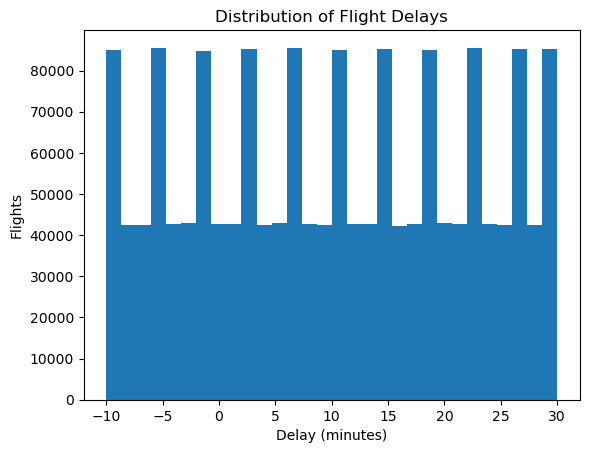

In [13]:
import matplotlib.pyplot as plt

plt.hist(df["DelayMinutes"], bins=30)
plt.xlabel("Delay (minutes)")
plt.ylabel("Flights")
plt.title("Distribution of Flight Delays")
plt.show()

In [14]:
df["ScheduledDeparture"] = pd.to_datetime(df["ScheduledDeparture"])

In [15]:
df["DepartureHour"] = df["ScheduledDeparture"].dt.hour

In [16]:
df["Month"] = df["ScheduledDeparture"].dt.month

In [17]:
df["DayOfWeek"] = df["ScheduledDeparture"].dt.dayofweek

In [18]:
df["Delayed"] = (df["DelayMinutes"] >= 15).astype(int)

In [19]:
df.to_csv("../data/processed/clean_flights.csv", index=False)

In [20]:
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1747627 entries, 0 to 1747626
Data columns (total 20 columns):
 #   Column              Dtype         
---  ------              -----         
 0   FlightID            int64         
 1   Airline             object        
 2   FlightNumber        int64         
 3   Origin              object        
 4   Destination         object        
 5   ScheduledDeparture  datetime64[ns]
 6   ActualDeparture     object        
 7   ScheduledArrival    object        
 8   ActualArrival       object        
 9   DelayMinutes        int64         
 10  DelayReason         object        
 11  Cancelled           bool          
 12  Diverted            bool          
 13  AircraftType        object        
 14  TailNumber          object        
 15  Distance            int64         
 16  DepartureHour       int32         
 17  Month               int32         
 18  DayOfWeek           int32         
 19  Delayed             int64         
dtypes:

FlightID                   0
Airline                    0
FlightNumber               0
Origin                     0
Destination                0
ScheduledDeparture         0
ActualDeparture            0
ScheduledArrival           0
ActualArrival              0
DelayMinutes               0
DelayReason           468873
Cancelled                  0
Diverted                   0
AircraftType               0
TailNumber                 0
Distance                   0
DepartureHour              0
Month                      0
DayOfWeek                  0
Delayed                    0
dtype: int64

In [21]:
df["Origin"].value_counts().head(20)

Origin
ORD    350059
ATL    349767
LAX    349667
JFK    349208
DFW    348926
Name: count, dtype: int64